# Experiment 01 — Baseline TFNO2D (Kaggle First Run)

This notebook is the **first official baseline run** using the competition's 16 input features only.
All reusable code lives in `src/`.

**Notes:**
- Uses official min-max normalization (`feat_min_max.mat`)
- Uses strict temporal blocking (`OCT_16` validation)
- Uses baseline `tfno2d` model (no extra auxiliary channels)
- Uses persistence gate from EDA to verify learning quality

**Pipeline:**  
1. Load config  
2. Load official normalization bounds  
3. Build train/validation loaders  
4. Train baseline TFNO2D and compare against persistence  
5. Run inference and save `preds.npy`

In [ ]:
/kaggle/input/datasets/khushisingh942004/aisehack

SRC_ROOT: /kaggle/input/datasets/ronitraj1/ronit-pm25-src


## 1. Configuration

In [9]:
cfg = load_config()

seed_everything(cfg['training']['seed'])
print_device_info(cfg['device'])

print(f"Base features ({cfg['features']['n_features']}): {cfg['features']['base']}")
print(f"Aux features  ({len(cfg['features']['aux'])}): {cfg['features']['aux']}")
print(f"Input channels: {cfg['features']['input_channels']}")
print(f"Train months: {cfg['data']['train_months']}")
print(f"Val month:    {cfg['data']['val_month']}")
print(f"Model type:   {cfg['model']['type']}")
print(f"Data root:    {cfg['paths']['data']}")

Device: cuda
GPU: Tesla P100-PCIE-16GB
GPU Memory: 17.1 GB
Base features (16): ['cpm25', 'u10', 'v10', 'pblh', 'rain', 't2', 'q2', 'swdown', 'psfc', 'PM25', 'SO2', 'NOx', 'NH3', 'NMVOC_e', 'NMVOC_finn', 'bio']
Aux features  (0): []
Input channels: 16
Train months: ['APRIL_16', 'JULY_16', 'DEC_16']
Val month:    OCT_16
Model type:   tfno2d
Data root:    /kaggle/input/datasets/khushisingh942004/aisehack


## 2. Load Normalization Bounds (feat_min_max.mat)

In [10]:
# Load official min-max bounds from feat_min_max.mat
bounds = load_minmax_bounds(cfg)

print(f"Loaded bounds for {len(bounds)} features")
print(f"Source: {cfg['paths']['min_max']}")

# Sanity check: print ranges, flag any zero-range features
sanity_check_bounds(bounds, cfg['features']['all'])

Loaded bounds for 16 features
Source: /kaggle/input/datasets/khushisingh942004/aisehack/stats/feat_min_max.mat

Feature                    Min            Max          Range   OK?
─────────────────────────────────────────────────────────────────
cpm25                 0.993999        1465.25        1464.25  ✓
u10                   -26.8288        29.0259        55.8547  ✓
v10                   -29.2164        31.9303        61.1467  ✓
pblh                   52.1152        6271.37        6219.25  ✓
rain                         0        96.6274        96.6274  ✓
t2                     223.531        324.774        101.244  ✓
q2                           0      0.0458545      0.0458545  ✓
swdown                       0        1320.28        1320.28  ✓
psfc                   47353.1         102295        54941.8  ✓
PM25                         0    1.42691e-07    1.42691e-07  ✓
SO2                          0    5.43537e-08    5.43537e-08  ✓
NOx                          0    7.97706e-08    7.

## 3. Load & Preprocess Training / Validation Data

Baseline preprocessing used here:
- official `feat_min_max.mat` normalization for all 16 competition features
- strict temporal blocking (`OCT_16` held out entirely)
- lazy sliding-window dataset to avoid materializing massive tensors

In [11]:
print("Loading + normalizing training months ...")
train_data = load_all_months(cfg, cfg['data']['train_months'], bounds)

print("\nLoading + normalizing validation month ...")
val_data = load_all_months(cfg, [cfg['data']['val_month']], bounds)

Loading + normalizing training months ...
  Loading APRIL_16 ... OK
  Loading JULY_16 ... OK
  Loading DEC_16 ... OK

Loading + normalizing validation month ...
  Loading OCT_16 ... OK


In [12]:
train_dl, val_dl = get_dataloaders(cfg, train_data, val_data, bounds)
print("Batch shape check ...")
xb, yb = next(iter(train_dl))
print(f"  x: {tuple(xb.shape)}  (B, C={xb.shape[1]}, T={xb.shape[2]}, H={xb.shape[3]}, W={xb.shape[4]})")
print(f"  y: {tuple(yb.shape)}  (B, H, W, T_out={yb.shape[3]})")
print(f"  x range: [{xb.min():.3f}, {xb.max():.3f}]")
print(f"  y range: [{yb.min():.3f}, {yb.max():.3f}]")
print("  Baseline mode: only 16 official features (no auxiliary channels)")

  Train samples: 1,059  |  Val samples: 179
Batch shape check ...
  x: (4, 16, 26, 140, 124)  (B, C=16, T=26, H=140, W=124)
  y: (4, 140, 124, 16)  (B, H, W, T_out=16)
  x range: [0.000, 0.994]
  y range: [0.000, 0.588]
  Baseline mode: only 16 official features (no auxiliary channels)


## 4. Build & Train Baseline TFNO2D

In [13]:
model = build_model(cfg)
print(f"Parameters: {count_parameters(model):,}")
print(f"Using model: {cfg['model']['type']}")
print("Expected first target: beat persistence gate before trying larger architectures")

Parameters: 13,161,424
Using model: tfno2d
Expected first target: beat persistence gate before trying larger architectures


In [ ]:
# ── Weights & Biases — initialise run ─────────────────────────────────────────
# Set wandb.enabled = true in configs/config.yaml (or override below) to activate.
# Override run-name / tags for experiment bookkeeping:
# cfg['wandb']['run_name'] = 'res_stunet-logrmse-oct-val'
# cfg['wandb']['tags']     = ['pm25', 'res_stunet', 'oct_val', 'aisehack']

wandb_run = init_wandb(cfg)  # returns None when disabled

In [ ]:
history = train(cfg, model, train_dl, val_dl, bounds=bounds, wandb_run=wandb_run)


────────────────────────────────────────────────────────────
  Persistence gate  (normalized RMSE): 0.0208
  Persistence gate  (physical RMSE) : 30.83 µg/m³
────────────────────────────────────────────────────────────

Epoch   1/60 | Train: 0.0292 | Val: 0.0212  |  ~31.0 µg/m³ | ValPersist: 0.0153 | Best: 0.0212  ← saved
Epoch   2/60 | Train: 0.0143 | Val: 0.0213  |  ~31.1 µg/m³ | ValPersist: 0.0153 | Best: 0.0212  (no improvement 1/8)
Epoch   3/60 | Train: 0.0122 | Val: 0.0174  |  ~25.5 µg/m³ | ValPersist: 0.0153 | Best: 0.0174  ← saved
Epoch   4/60 | Train: 0.0112 | Val: 0.0171  |  ~25.0 µg/m³ | ValPersist: 0.0153 | Best: 0.0171  ← saved
Epoch   5/60 | Train: 0.0095 | Val: 0.0177  |  ~25.9 µg/m³ | ValPersist: 0.0153 | Best: 0.0171  (no improvement 1/8)
  ✓  Persistence gate MET: val_rmse=0.0177  <  persistence=0.0208 (gap=-0.0031)
Epoch   6/60 | Train: 0.0088 | Val: 0.0177  |  ~25.9 µg/m³ | ValPersist: 0.0153 | Best: 0.0171  (no improvement 2/8)
Epoch   7/60 | Train: 0.0077 | Val: 0

### Training Curves

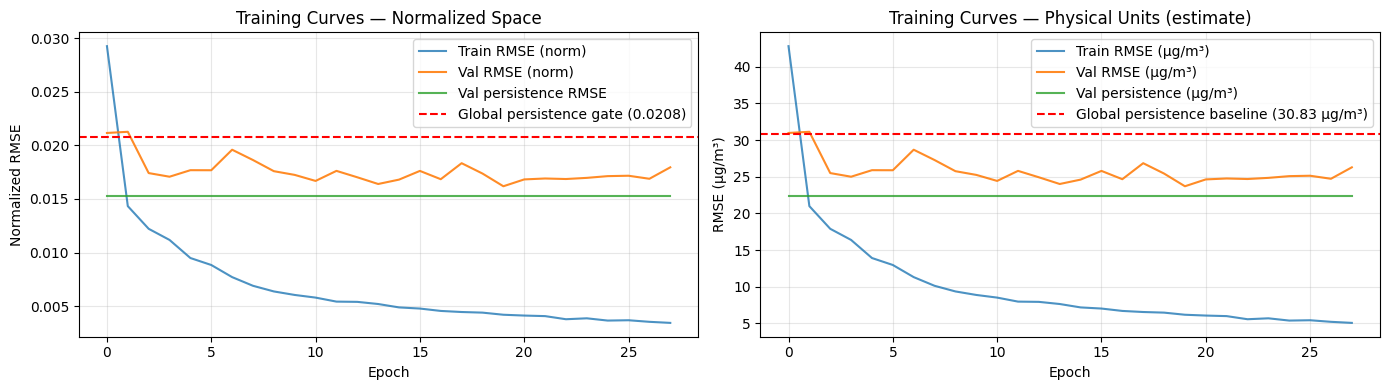

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.train import PERSISTENCE_RMSE_NORM, PERSISTENCE_RMSE_PHYS

fmin, fmax = bounds['cpm25']
cpm_range  = fmax - fmin

epochs_x   = list(range(1, len(history['val_loss']) + 1))

# ── Figure 1: Normalized RMSE + Physical RMSE ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(epochs_x, history['train_loss'],       label='Train RMSE (norm)', alpha=0.8)
ax.plot(epochs_x, history['val_loss'],         label='Val RMSE (norm)',   alpha=0.9)
if 'val_persistence' in history:
    ax.plot(epochs_x, history['val_persistence'], label='Val persistence RMSE', alpha=0.8, linestyle='--')
ax.axhline(PERSISTENCE_RMSE_NORM, color='red', linestyle=':', label=f'Global persistence gate ({PERSISTENCE_RMSE_NORM})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Normalized RMSE')
ax.set_title('Training Curves — Normalized Space'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_x, [v * cpm_range for v in history['train_loss']], label='Train RMSE (µg/m³)', alpha=0.8)
ax.plot(epochs_x, [v * cpm_range for v in history['val_loss']],   label='Val RMSE (µg/m³)',   alpha=0.9)
if 'val_persistence' in history:
    ax.plot(epochs_x, [v * cpm_range for v in history['val_persistence']], label='Val persistence (µg/m³)', alpha=0.8, linestyle='--')
ax.axhline(PERSISTENCE_RMSE_PHYS, color='red', linestyle=':', label=f'Persistence baseline ({PERSISTENCE_RMSE_PHYS} µg/m³)')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('Training Curves — Physical Units (estimate)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/images/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 2: Selection metric + LR + Grad norm ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ax = axes[0]
ax.plot(epochs_x, history.get('selection_metric', history['val_loss']), color='purple', label='Selection metric')
best_ep  = int(np.argmin(history.get('selection_metric', history['val_loss'])))
ax.axvline(best_ep + 1, color='green', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep+1})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Selection Metric'); ax.set_title('Selection Metric (lower = better checkpoint)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_x, history.get('train_objective', history['train_loss']), label='Train objective', color='darkorange')
ax.plot(epochs_x, history.get('val_objective',   history['val_loss']),   label='Val objective',   color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Objective Loss'); ax.set_title('Objective Loss (task-specific)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
# Persistence ratio: val_rmse / batch_persistence — < 1 means beating local persistence
if 'val_persistence' in history:
    ratios = [v / p if p > 0 else 1.0 for v, p in zip(history['val_loss'], history['val_persistence'])]
    ax.plot(epochs_x, ratios, color='teal', label='val_rmse / batch_persistence')
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Parity (= persistence)')
    ax.axhline(PERSISTENCE_RMSE_NORM / (history['val_persistence'][0] if history['val_persistence'][0] > 0 else 1),
               color='orange', linestyle=':', alpha=0.5, label='Global persistence line')
    ax.set_ylabel('Ratio'); ax.legend()
ax.set_xlabel('Epoch'); ax.set_title('Val RMSE ÷ Batch-Persistence (< 1 = beating baseline)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/images/diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 3: Gap from global persistence gate ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
gaps = [v - PERSISTENCE_RMSE_NORM for v in history['val_loss']]
colors = ['green' if g < 0 else 'crimson' for g in gaps]
ax.bar(epochs_x, gaps, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val RMSE − Persistence gate')
ax.set_title('Gap from Persistence Gate (green = beating baseline)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/images/persistence_gap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Upload all charts to W&B ──────────────────────────────────────────────────
try:
    import wandb
    if wandb_run is not None:
        wandb_run.log({
            'charts/training_curves':   wandb.Image('../outputs/images/training_curves.png'),
            'charts/diagnostics':       wandb.Image('../outputs/images/diagnostics.png'),
            'charts/persistence_gap':   wandb.Image('../outputs/images/persistence_gap.png'),
        })
        print("Charts uploaded to W&B.")
except Exception as _e:
    print(f"W&B image upload skipped: {_e}")

# ── Print leaderboard proxy summary ───────────────────────────────────────────
best_val     = min(history['val_loss'])
best_val_phys = best_val * cpm_range
ratio_global  = best_val / PERSISTENCE_RMSE_NORM

print(f"\n{'─'*55}")
print(f"  Best val RMSE (norm):     {best_val:.5f}")
print(f"  Best val RMSE (phys est): {best_val_phys:.2f} µg/m³")
print(f"  Persistence gate (norm):  {PERSISTENCE_RMSE_NORM:.4f}")
print(f"  Persistence gate (phys):  {PERSISTENCE_RMSE_PHYS:.2f} µg/m³")
print(f"  Ratio (norm): {ratio_global:.4f}  {'✓ BEATING baseline' if ratio_global < 1 else '✗ still above baseline'}")
print(f"{'─'*55}")

## 5. Inference & Submit

In [16]:
import torch

model.load_state_dict(torch.load(cfg['paths']['model_save'], map_location=cfg['device']))
preds = run_inference(cfg, model, bounds)
print('Done!')

Test batch shape: (16, 16, 26, 140, 124) (chunked mode)
Output shape: (996, 140, 124, 16) | range: [0.0, 1721.5] µg/m³
preds.npy saved → /kaggle/working/preds.npy
Done!


In [ ]:
import os
import numpy as np

# ------------------------------
# Environment-aware path helpers
# ------------------------------
def first_existing(paths):
    return next((p for p in paths if p and os.path.exists(p)), None)

on_kaggle = os.path.exists('/kaggle')

# Resolve source/project root
if 'SRC_ROOT' in globals() and isinstance(SRC_ROOT, str):
    src_root = SRC_ROOT
else:
    cwd = os.getcwd()
    candidate_roots = [
        os.path.abspath(os.path.join(cwd, '..')),
        os.path.abspath(os.path.join(cwd, '../..')),
        os.path.abspath(cwd),
        os.path.abspath('/home/raj/Documents/CODING/Hackathon/ANRF_AISEHack_Code/Ronit'),
        '/kaggle/input/ronit-pm25-src',
    ]
    src_root = first_existing([r for r in candidate_roots if os.path.exists(os.path.join(r, 'outputs'))]) or candidate_roots[0]

# Resolve data root (works for local + Kaggle competition/input variants)
if 'cfg' in globals() and isinstance(cfg, dict) and 'paths' in cfg:
    cfg_output = cfg['paths'].get('output')
    cfg_model_save = cfg['paths'].get('model_save', '')
    cfg_temp = cfg['paths'].get('temp', '')
    data_root = cfg['paths'].get('data')
else:
    cfg_output = None
    cfg_model_save = ''
    cfg_temp = ''
    data_root = None

data_candidates = [
    data_root,
    os.environ.get('AISEHACK_DATA'),
    '/kaggle/input/aisehack-theme-2',
    '/kaggle/input/competitions/aisehack-theme-2',
    '/kaggle/input/datasets/khushisingh942004/aisehack',
    os.path.abspath(os.path.join(src_root, '..', 'aisehack-theme-2')),
    os.path.abspath(os.path.join(src_root, 'aisehack-theme-2')),
]
data_root = first_existing([p for p in data_candidates if p and os.path.exists(os.path.join(p, 'test_in'))])
if data_root is None:
    raise FileNotFoundError('Could not locate data root containing test_in/. Set AISEHACK_DATA or attach competition data.')

# ------------------------------
# Locate preds.npy
# ------------------------------
pred_candidates = [
    '/kaggle/working/preds.npy' if on_kaggle else None,
    cfg_output,
    os.path.join(os.path.dirname(cfg_model_save), 'preds.npy') if cfg_model_save else None,
    os.path.join(os.path.dirname(cfg_temp), 'preds.npy') if cfg_temp else None,
    os.path.abspath(os.path.join(src_root, 'outputs', 'models', 'preds.npy')),
    os.path.abspath(os.path.join(src_root, 'outputs', 'submissions', 'preds.npy')),
]
preds_path = first_existing(pred_candidates)
if preds_path is None:
    raise FileNotFoundError('Could not find preds.npy in expected locations (including /kaggle/working).')

preds = np.load(preds_path)
print(f"Using preds: {preds_path}")
print(f"preds shape (raw): {preds.shape}")

# ------------------------------
# Load available test history
# ------------------------------
test_cpm25_path = os.path.join(data_root, 'test_in', 'cpm25.npy')
test_cpm25_hist = np.load(test_cpm25_path)
print(f"Using test history: {test_cpm25_path}")
print(f"test_in/cpm25 shape: {test_cpm25_hist.shape}")

# Expected:
# test_cpm25_hist: (N, 10, H, W)
# preds:           (N, H, W, 16)

# Handle common prediction layout variant: (N, 16, H, W)
if preds.ndim == 4 and preds.shape[1] == 16 and preds.shape[-1] != 16:
    preds = np.transpose(preds, (0, 2, 3, 1))
    print(f"preds shape (transposed to NHWT): {preds.shape}")

if preds.ndim != 4 or preds.shape[-1] != 16:
    raise ValueError(f"Expected preds shape like (N, H, W, 16), got {preds.shape}")

n, h, w, t_out = preds.shape
if t_out != 16:
    raise ValueError(f"Expected 16 forecast steps, got {t_out}")
if test_cpm25_hist.shape[0] != n or test_cpm25_hist.shape[2] != h or test_cpm25_hist.shape[3] != w:
    raise ValueError(
        'Spatial/sample mismatch between preds and test history: '
        f'preds={preds.shape}, test_hist={test_cpm25_hist.shape}'
    )

last_obs = test_cpm25_hist[:, -1, :, :]  # (N, H, W)

# 1) Horizon-1 consistency with latest observation
h1_pred = preds[..., 0]
rmse_h1_vs_last = float(np.sqrt(np.mean((h1_pred - last_obs) ** 2)))
mae_h1_vs_last = float(np.mean(np.abs(h1_pred - last_obs)))

# 2) Distance from persistence baseline over all forecast horizons
persistence = np.repeat(last_obs[..., None], preds.shape[-1], axis=-1)
rmse_all_vs_persistence = float(np.sqrt(np.mean((preds - persistence) ** 2)))
mae_all_vs_persistence = float(np.mean(np.abs(preds - persistence)))

# 3) Temporal smoothness inside forecast trajectory
step_delta = np.diff(preds, axis=-1)
mean_abs_step_change = float(np.mean(np.abs(step_delta)))

print('\nProxy scores (lower is generally better for RMSE/MAE):')
print(f"- RMSE(H+1 vs last observed):        {rmse_h1_vs_last:.4f}")
print(f"- MAE(H+1 vs last observed):         {mae_h1_vs_last:.4f}")
print(f"- RMSE(all horizons vs persistence): {rmse_all_vs_persistence:.4f}")
print(f"- MAE(all horizons vs persistence):  {mae_all_vs_persistence:.4f}")
print(f"- Mean abs step change (H to H+1):   {mean_abs_step_change:.4f}")

print('\nNote: Official competition score is computed on hidden future targets on Kaggle.')

In [ ]:
# ── Log post-inference proxy scores to W&B then finish run ────────────────────
# These scalars let you compare across runs on the W&B dashboard without
# needing the hidden leaderboard — a lower proxy_rmse_h1 typically tracks well.

try:
    import wandb as _wb
    if wandb_run is not None:
        wandb_run.log({
            'inference/proxy_rmse_h1_vs_last':     rmse_h1_vs_last,
            'inference/proxy_mae_h1_vs_last':      mae_h1_vs_last,
            'inference/proxy_rmse_all_vs_persist': rmse_all_vs_persistence,
            'inference/proxy_mae_all_vs_persist':  mae_all_vs_persistence,
            'inference/mean_abs_step_change':      mean_abs_step_change,
        })
        print("Proxy scores logged to W&B.")
except Exception as _e:
    print(f"Proxy score W&B log skipped: {_e}")

# Finish the W&B run (uploads remaining data, closes the run)
finish_wandb(wandb_run, history, bounds, cfg)